# CS 540 Module Five Activity: Data Visualizations
### Dataset: College Scorecard — Most Recent Cohorts, Field of Study

This notebook prepares, cleans, and visualizes the College Scorecard field-of-study
data set. The goal is to see whether bachelor's-degree fields of study group into
distinct earnings/debt profiles, and to visualize those patterns six different ways.


## Part One, Step 1: Prepare the data set

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

# Load the raw data set
raw = pd.read_csv('Most-Recent-Cohorts-Field-of-Study.csv', low_memory=False)
print('Raw shape:', raw.shape)
raw.head()

Raw shape: (229188, 174)


,UNITID,OPEID6,INSTNM,CONTROL,MAIN,CIPCODE,CIPDESC,CREDLEV,CREDDESC,IPEDSCOUNT1,...,EARN_COUNT_PELL_WNE_5YR,EARN_PELL_WNE_MDN_5YR,EARN_COUNT_NOPELL_WNE_5YR,EARN_NOPELL_WNE_MDN_5YR,EARN_COUNT_MALE_WNE_5YR,EARN_MALE_WNE_MDN_5YR,EARN_COUNT_NOMALE_WNE_5YR,EARN_NOMALE_WNE_MDN_5YR,EARN_COUNT_HIGH_CRED_5YR,EARN_IN_STATE_5YR
0,100654.0,1002,Alabama A & M University,Public,1,100,"Agriculture, General.",3,Bachelor's Degree,NaN,...,PS,PS,PS,PS,PS,PS,PS,PS,PS,PS
1,100654.0,1002,Alabama A & M University,Public,1,101,Agricultural Business and Management.,3,Bachelor's Degree,NaN,...,PS,PS,PS,PS,PS,PS,PS,PS,PS,PS
2,100654.0,1002,Alabama A & M University,Public,1,109,Animal Sciences.,3,Bachelor's Degree,3.0,...,PS,PS,PS,PS,PS,PS,PS,PS,PS,PS
3,100654.0,1002,Alabama A & M University,Public,1,110,Food Science and Technology.,3,Bachelor's Degree,7.0,...,PS,PS,PS,PS,PS,PS,PS,PS,PS,PS
4,100654.0,1002,Alabama A & M University,Public,1,110,Food Science and Technology.,5,Master's Degree,4.0,...,PS,PS,PS,PS,PS,PS,PS,PS,PS,PS


**Column selection.** The raw file has 174 columns, most of which are debt/earnings
breakdowns by sex, Pell status, or repayment cohort that this activity does not need.
I kept only the columns required to compare fields of study on earnings and debt:
the field-of-study description, credential level, and four numeric outcome columns
(1-, 4-, and 5-year median earnings, and median debt).

**Filtering.** I restricted the data to Bachelor's-degree programs (`CREDLEV == 3`)
at each institution's main campus (`MAIN == 1`) so that every row is comparable —
mixing associate, certificate, and graduate credentials together would blend very
different earnings scales into the same clusters.

In [2]:
# TO-DO: select the columns needed for this analysis and filter to a
# comparable population (bachelor's degree, main campus)
keep_cols = ['UNITID', 'CIPDESC', 'CREDLEV', 'CREDDESC', 'MAIN',
             'EARN_MDN_1YR', 'EARN_MDN_4YR', 'EARN_MDN_5YR', 'DEBT_ALL_STGP_ANY_MDN']
df = raw[keep_cols].copy()
df = df[(df['CREDLEV'] == 3) & (df['MAIN'] == 1)]
print('After filtering to bachelor\'s / main campus:', df.shape)
df.head()

After filtering to bachelor's / main campus: (68977, 9)


,UNITID,CIPDESC,CREDLEV,CREDDESC,MAIN,EARN_MDN_1YR,EARN_MDN_4YR,EARN_MDN_5YR,DEBT_ALL_STGP_ANY_MDN
0,100654.0,"Agriculture, General.",3,Bachelor's Degree,1,PS,PS,PS,PS
1,100654.0,Agricultural Business and Management.,3,Bachelor's Degree,1,PS,PS,PS,PS
2,100654.0,Animal Sciences.,3,Bachelor's Degree,1,PS,PS,PS,PS
3,100654.0,Food Science and Technology.,3,Bachelor's Degree,1,PS,PS,PS,PS
6,100654.0,Plant Sciences.,3,Bachelor's Degree,1,PS,PS,PS,PS


## Part One, Step 2: Clean the data set

**Missing / invalid values.** The College Scorecard uses the strings `"PS"`
(privacy-suppressed, small cell size) and `"NA"` (not applicable) inside numeric
columns, so pandas reads those columns as text. I coerced the four outcome columns
to numeric — which turns `"PS"`/`"NA"` into `NaN` — and dropped any row that is
missing one of them, since a program can't contribute to the earnings/debt profile
without all four values.

**Column names.** `EARN_MDN_1YR`, `EARN_MDN_4YR`, `EARN_MDN_5YR`, and
`DEBT_ALL_STGP_ANY_MDN` are the original (unclear) source names; I keep them through
cleaning and rename to plain-English names once the data is aggregated below.

**Grouping.** A single field of study (e.g., "Computer Science") appears once per
institution that offers it — thousands of rows. To compare *fields*, not
individual college programs, I aggregated to the mean of each numeric column per
`CIPDESC` (field-of-study description), and kept only fields with at least 15
reporting programs so each point in the later charts represents a reasonably
stable estimate.

In [3]:
# TO-DO: convert outcome columns to numeric and drop rows with missing values
num_cols = ['EARN_MDN_1YR', 'EARN_MDN_4YR', 'EARN_MDN_5YR', 'DEBT_ALL_STGP_ANY_MDN']
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df = df.dropna(subset=num_cols)
print('After removing missing/invalid values:', df.shape)

# TO-DO: aggregate individual programs up to one row per field of study
field = (df.groupby('CIPDESC')
           .agg(n_programs=('UNITID', 'count'),
                earn_1yr=('EARN_MDN_1YR', 'mean'),
                earn_4yr=('EARN_MDN_4YR', 'mean'),
                earn_5yr=('EARN_MDN_5YR', 'mean'),
                debt=('DEBT_ALL_STGP_ANY_MDN', 'mean'))
           .reset_index())

# keep only fields with enough reporting programs to be a stable estimate
field = field[field['n_programs'] >= 15].reset_index(drop=True)
field['CIPDESC'] = field['CIPDESC'].str.rstrip('.')

print('Field-of-study level table:', field.shape)
field.dtypes

After removing missing/invalid values: (17277, 9)
Field-of-study level table: (142, 6)


CIPDESC           str
n_programs      int64
earn_1yr      float64
earn_4yr      float64
earn_5yr      float64
debt          float64
dtype: object

In [4]:
field.describe()

,n_programs,earn_1yr,earn_4yr,earn_5yr,debt
count,142.000000,142.000000,142.000000,142.000000,142.000000
mean,116.971831,44635.954760,56120.153354,64860.713697,24026.103280
std,161.539005,14534.104881,15220.692657,17076.287196,2429.345698
min,15.000000,21211.679739,29652.934641,34358.810458,18629.000000
25%,27.000000,33697.574277,45201.286007,52046.103030,22494.988331
50%,49.500000,39783.497867,51538.063467,59994.648985,23898.420444
75%,127.750000,55753.212867,67107.533470,77220.754499,25337.112132
max,943.000000,80208.188679,97611.642512,113284.719807,33029.035461


## Part One, Step 3: Create the visualizations

**Structuring the data for the charts.** All six visuals below are built from the
same cleaned, field-level table. The four numeric columns (`earn_1yr`, `earn_4yr`,
`earn_5yr`, `debt`) are standardized (`StandardScaler`) so that earnings — which are
on a scale of tens of thousands — don't dominate the clustering just because the
numbers are bigger than debt. The standardized features feed a K-Means clustering
(k = 4) and a 2-component PCA, which several of the charts below are built on.

In [5]:
# TO-DO: scale features and run PCA
feature_cols = ['earn_1yr', 'earn_4yr', 'earn_5yr', 'debt']
X = field[feature_cols].values

scaler = StandardScaler()
Xs = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(Xs)
field['pc1'], field['pc2'] = pcs[:, 0], pcs[:, 1]

print('Explained variance ratio:', pca.explained_variance_ratio_)

# TO-DO: run K-Means clustering on the standardized features
k = 4
km = KMeans(n_clusters=k, random_state=42, n_init=10)
field['cluster'] = km.fit_predict(Xs)

field['cluster'].value_counts().sort_index()

Explained variance ratio: [0.72694968 0.25319689]


cluster
0    30
1    35
2    57
3    20
Name: count, dtype: int64

### Visual A: Dendrogram

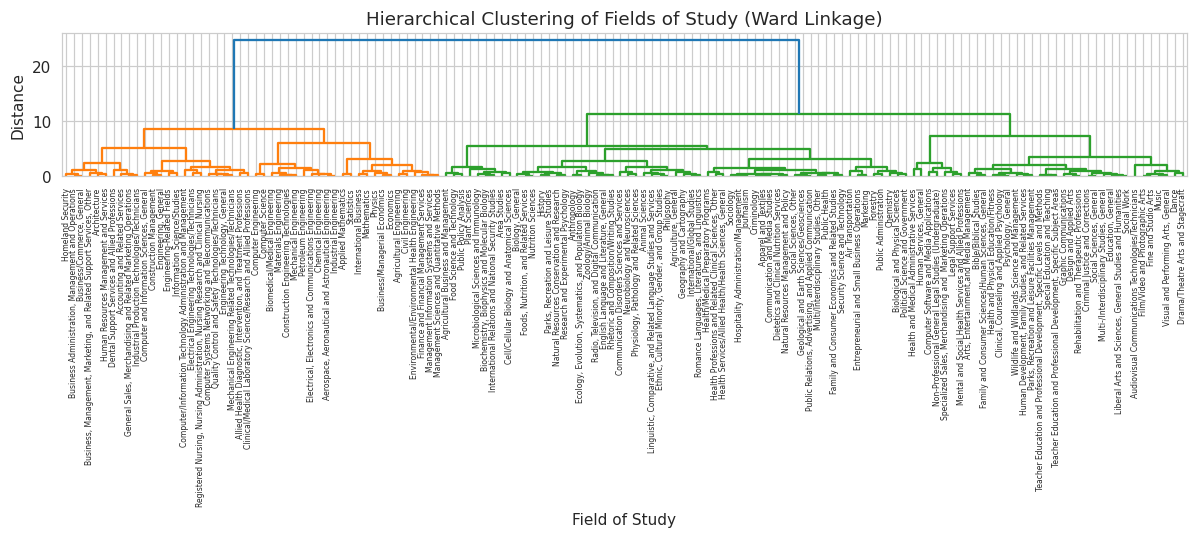

In [6]:
# TO-DO: build a dendrogram from hierarchical (Ward) clustering
Z = linkage(Xs, method='ward')

plt.figure(figsize=(11, 5))
dendrogram(Z, labels=field['CIPDESC'].values, leaf_rotation=90, leaf_font_size=5)
plt.title('Hierarchical Clustering of Fields of Study (Ward Linkage)')
plt.xlabel('Field of Study')
plt.ylabel('Distance')
plt.tight_layout()
plt.savefig('dendrogram.png')
plt.show()

### Visual B: PCA scatterplot

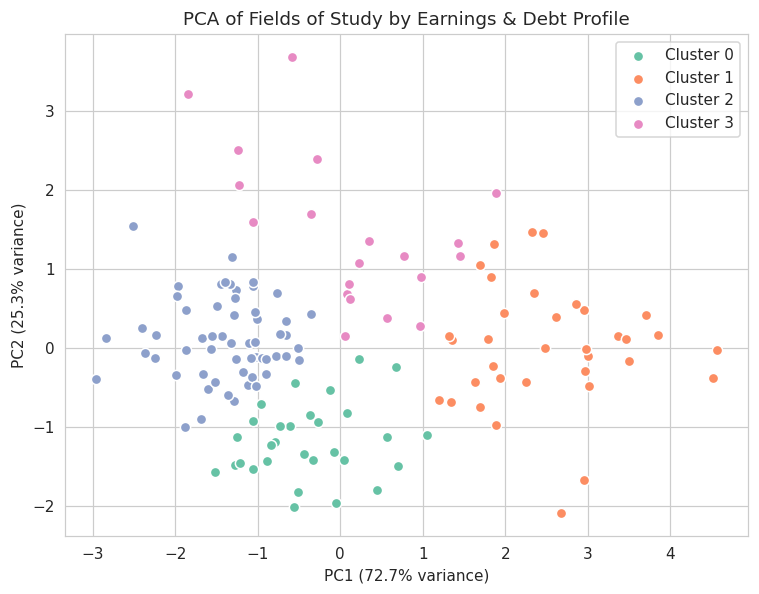

In [7]:
# TO-DO: plot the fields of study on their first two principal components,
# colored by K-Means cluster
palette = sns.color_palette('Set2', k)

plt.figure(figsize=(7, 5.5))
for c in range(k):
    sub = field[field['cluster'] == c]
    plt.scatter(sub['pc1'], sub['pc2'], label=f'Cluster {c}', s=45,
                color=palette[c], edgecolor='white')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('PCA of Fields of Study by Earnings & Debt Profile')
plt.legend()
plt.tight_layout()
plt.savefig('pca_scatterplot.png')
plt.show()

### Visual C: Cluster size distribution

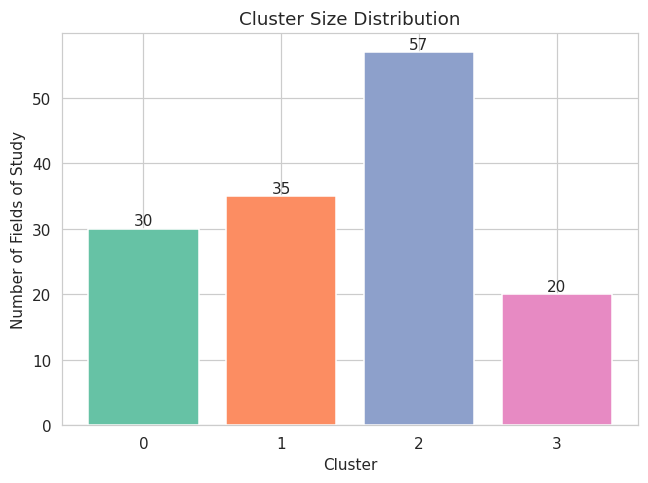

In [8]:
# TO-DO: bar chart of how many fields of study fall in each cluster
plt.figure(figsize=(6, 4.5))
counts = field['cluster'].value_counts().sort_index()
bars = plt.bar(counts.index.astype(str), counts.values,
                color=[palette[i] for i in counts.index])
plt.xlabel('Cluster')
plt.ylabel('Number of Fields of Study')
plt.title('Cluster Size Distribution')
for b in bars:
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
              int(b.get_height()), ha='center')
plt.tight_layout()
plt.savefig('cluster_size_distribution.png')
plt.show()

### Visual D: Feature importance heatmap

This heatmap shows how much each original feature (1-, 4-, 5-year earnings, and
debt) contributes to the two principal components used above — effectively, which
features drive the separation seen in the PCA scatterplot.

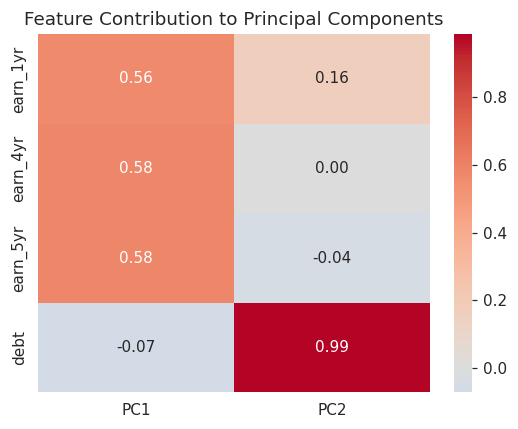

In [9]:
# TO-DO: heatmap of how strongly each feature loads onto each principal component
loadings = pd.DataFrame(pca.components_.T, index=feature_cols, columns=['PC1', 'PC2'])

plt.figure(figsize=(5, 4))
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Contribution to Principal Components')
plt.tight_layout()
plt.savefig('feature_importance_heatmap.png')
plt.show()

### Visual E: Trend chart

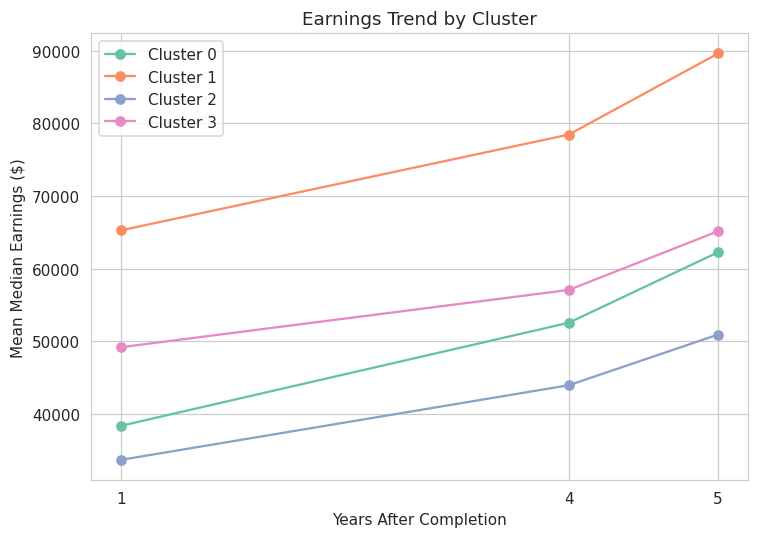

In [10]:
# TO-DO: line chart of mean earnings at 1, 4, and 5 years, one line per cluster
trend = field.groupby('cluster')[['earn_1yr', 'earn_4yr', 'earn_5yr']].mean().T
trend.index = [1, 4, 5]

plt.figure(figsize=(7, 5))
for c in trend.columns:
    plt.plot(trend.index, trend[c], marker='o', color=palette[c], label=f'Cluster {c}')
plt.xlabel('Years After Completion')
plt.ylabel('Mean Median Earnings ($)')
plt.title('Earnings Trend by Cluster')
plt.xticks([1, 4, 5])
plt.legend()
plt.tight_layout()
plt.savefig('trend_chart.png')
plt.show()

### Visual F: Scatterplot — earnings vs. debt

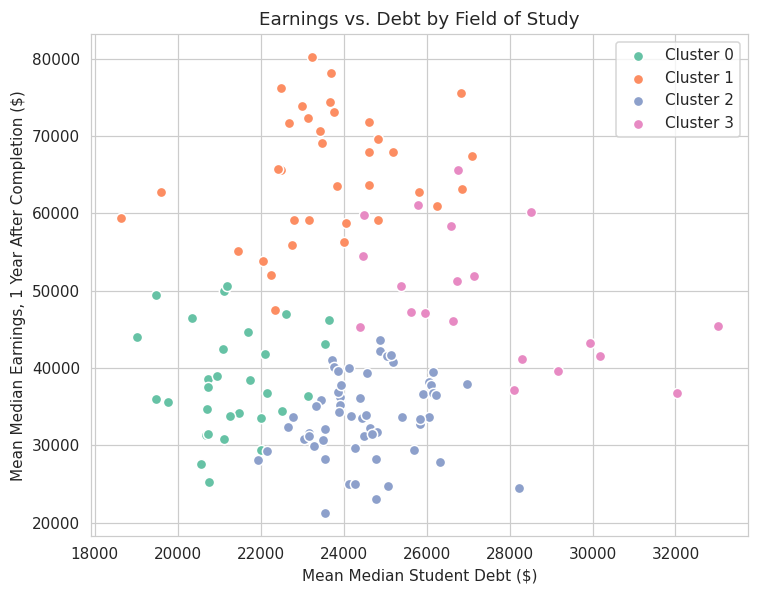

In [11]:
# TO-DO: scatterplot of 1-year earnings against debt, colored by cluster
plt.figure(figsize=(7, 5.5))
for c in range(k):
    sub = field[field['cluster'] == c]
    plt.scatter(sub['debt'], sub['earn_1yr'], label=f'Cluster {c}', s=45,
                color=palette[c], edgecolor='white')
plt.xlabel('Mean Median Student Debt ($)')
plt.ylabel('Mean Median Earnings, 1 Year After Completion ($)')
plt.title('Earnings vs. Debt by Field of Study')
plt.legend()
plt.tight_layout()
plt.savefig('scatterplot.png')
plt.show()

## Cluster composition (supporting detail for the reflection)

In [12]:
for c in sorted(field['cluster'].unique()):
    sub = field[field['cluster'] == c].sort_values('earn_1yr', ascending=False)
    print(f"--- Cluster {c}  (n={len(sub)},  "
          f"mean 1-yr earnings=${sub['earn_1yr'].mean():,.0f},  "
          f"mean debt=${sub['debt'].mean():,.0f}) ---")
    print(sub['CIPDESC'].head(5).tolist())
    print()

--- Cluster 0  (n=30,  mean 1-yr earnings=$38,363,  mean debt=$21,278) ---
['Mathematics', 'Food Science and Technology', 'Agricultural Business and Management', 'Public Administration', 'Public Policy Analysis']

--- Cluster 1  (n=35,  mean 1-yr earnings=$65,269,  mean debt=$23,598) ---
['Computer Engineering', 'Electrical, Electronics and Communications Engineering', 'Computer Science', 'Registered Nursing, Nursing Administration, Nursing Research and Clinical Nursing', 'Industrial Engineering']

--- Cluster 2  (n=57,  mean 1-yr earnings=$33,673,  mean debt=$24,529) ---
['Special Education and Teaching', 'Multi/Interdisciplinary Studies, Other', 'Teacher Education and Professional Development, Specific Subject Areas', 'Teacher Education and Professional Development, Specific Levels and Methods', 'Family and Consumer Economics and Related Studies']

--- Cluster 3  (n=20,  mean 1-yr earnings=$49,182,  mean debt=$27,464) ---
['Clinical/Medical Laboratory Science/Research and Allied Prof